# 09 — Claim Occurrence Explainability

## Objectif

L'objectif est d'expliquer les prédictions du modèle d'occurrence
de sinistre à l'aide de SHAP.

L'analyse porte sur :

- l'importance globale des variables ;
- la direction de leur contribution ;
- les relations non linéaires ;
- des explications locales de prédictions individuelles.

SHAP est appliqué au modèle XGBoost sous-jacent.

La calibration isotonic intervient ensuite comme transformation
des probabilités et n'est pas directement expliquée par TreeSHAP.

In [1]:
import pandas as pd
import numpy as np

import json
import joblib
import shap

import matplotlib.pyplot as plt

from pathlib import Path
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

RANDOM_STATE = 42

c:\Users\user\ai-business-advisor-v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:
    if path.exists():
        PROCESSED_DIR = path
        break

if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )

DATA_DIR = PROCESSED_DIR.parent
METADATA_DIR = DATA_DIR / "metadata"

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "claim_occurrence"
    / "explainability"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
occurrence = pd.read_csv(
    PROCESSED_DIR
    / "claim_occurrence_modeling_base.csv"
)

split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)

occurrence = occurrence.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)

development = (
    occurrence[
        occurrence["split"] == "development"
    ]
    .copy()
)

In [5]:
with open(
    METADATA_DIR / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:
    feature_manifest = json.load(f)

with open(
    METADATA_DIR / "claim_occurrence_candidate.json",
    "r",
    encoding="utf-8"
) as f:
    candidate_config = json.load(f)

In [6]:
config = feature_manifest[
    "claim_occurrence"
]

numeric_features = config[
    "numeric_features"
]

categorical_features = config[
    "categorical_features"
]

features = (
    numeric_features
    +
    categorical_features
)

X_dev = development[
    features
].copy()

y_dev = development[
    "has_claim"
].copy()

In [7]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [8]:
best_parameters = candidate_config[
    "best_parameters"
]

xgb_parameters = {
    key.replace(
        "model__",
        ""
    ): value

    for key, value
    in best_parameters.items()
}

In [9]:
explainability_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **xgb_parameters
            )
        )
    ]
)

In [10]:
explainability_pipeline.fit(
    X_dev,
    y_dev
)

print(
    "Explainability model entraîné."
)

Explainability model entraîné.


In [11]:
fitted_preprocessor = (
    explainability_pipeline
    .named_steps["preprocessor"]
)

fitted_xgb = (
    explainability_pipeline
    .named_steps["model"]
)

In [12]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Nombre de features après preprocessing :",
    len(feature_names)
)

Nombre de features après preprocessing : 47


In [13]:
SHAP_SAMPLE_SIZE = 5000

X_shap_raw = (
    X_dev
    .sample(
        n=min(
            SHAP_SAMPLE_SIZE,
            len(X_dev)
        ),
        random_state=RANDOM_STATE
    )
    .copy()
)

In [14]:
X_shap_transformed = (
    fitted_preprocessor
    .transform(
        X_shap_raw
    )
)

if sparse.issparse(
    X_shap_transformed
):
    X_shap_transformed = (
        X_shap_transformed
        .toarray()
    )

In [15]:
X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap_raw.index
)

X_shap_df.head()

,numeric__Exposure,numeric__VehPower,numeric__VehAge,numeric__DrivAge,numeric__BonusMalus,numeric__log_density,categorical__Area_A,categorical__Area_B,categorical__Area_C,categorical__Area_D,...,categorical__Region_R53,categorical__Region_R54,categorical__Region_R72,categorical__Region_R73,categorical__Region_R74,categorical__Region_R82,categorical__Region_R83,categorical__Region_R91,categorical__Region_R93,categorical__Region_R94
286629,0.13,5.0,10.0,36.0,51.0,3.970292,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
585189,1.00,6.0,3.0,77.0,50.0,5.690359,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
585740,0.27,7.0,11.0,58.0,50.0,5.690359,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117005,1.00,5.0,6.0,37.0,50.0,7.180831,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
387828,1.00,8.0,5.0,71.0,50.0,6.614726,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [16]:
explainer = shap.TreeExplainer(
    fitted_xgb
)

shap_values = explainer(
    X_shap_df
)

In [17]:
mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature":
        feature_names,

    "mean_abs_shap":
        mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_importance.head(20)

,feature,mean_abs_shap
0,numeric__Exposure,0.331484
4,numeric__BonusMalus,0.238343
2,numeric__VehAge,0.133114
15,categorical__VehBrand_B12,0.100790
3,numeric__DrivAge,0.087979
32,categorical__Region_R31,0.085669
40,categorical__Region_R73,0.075859
43,categorical__Region_R83,0.072873
27,categorical__Region_R22,0.072143
5,numeric__log_density,0.071506


In [18]:
shap_importance.to_csv(
    REPORT_DIR
    / "shap_global_importance.csv",
    index=False
)

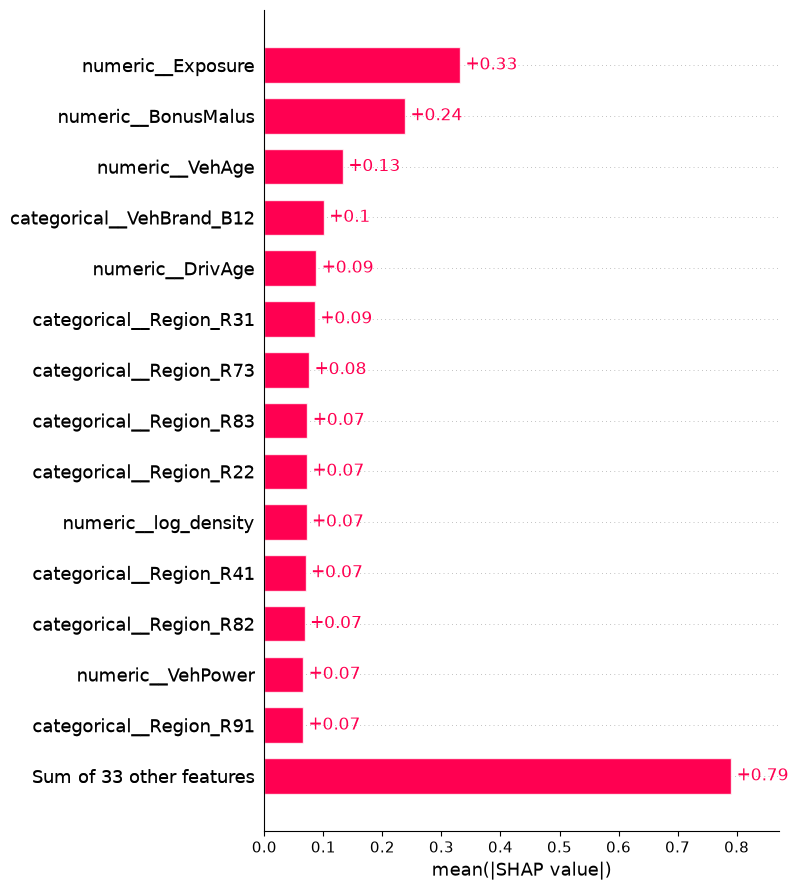

In [19]:
shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "shap_global_bar.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

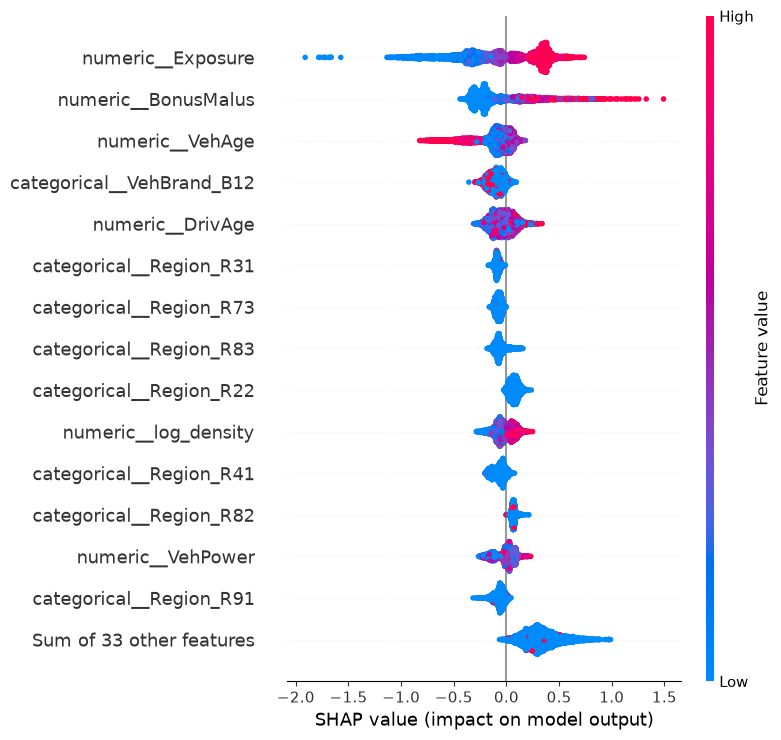

In [20]:
shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "shap_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [21]:
raw_probabilities = (
    explainability_pipeline
    .predict_proba(
        X_shap_raw
    )[:, 1]
)

highest_position = np.argmax(
    raw_probabilities
)

print(
    "Probabilité brute du cas :",
    raw_probabilities[
        highest_position
    ]
)

Probabilité brute du cas : 0.76437545


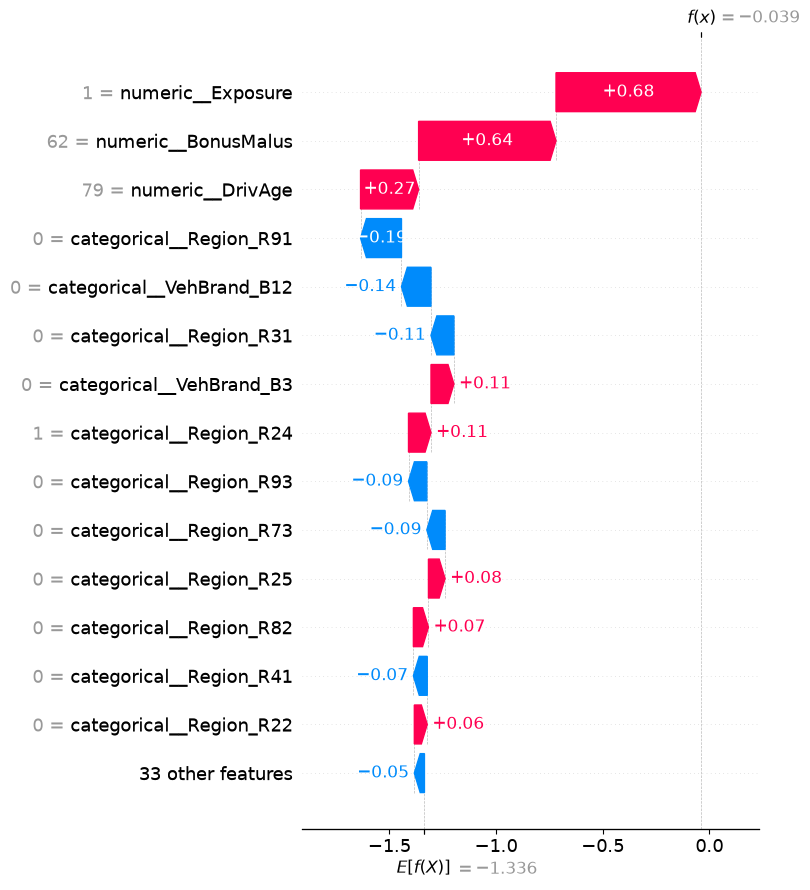

In [22]:
shap.plots.waterfall(
    shap_values[
        highest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "shap_local_high_risk.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
FINAL_MODEL_PATH = (
    DATA_DIR.parent
    / "artifacts"
    / "claim_occurrence_xgb_isotonic.joblib"
)

final_calibrated_model = joblib.load(
    FINAL_MODEL_PATH
)

In [24]:
selected_raw_case = (
    X_shap_raw
    .iloc[
        [highest_position]
    ]
)

raw_probability = (
    explainability_pipeline
    .predict_proba(
        selected_raw_case
    )[0, 1]
)

calibrated_probability = (
    final_calibrated_model
    .predict_proba(
        selected_raw_case
    )[0, 1]
)

print(
    "Raw XGBoost probability :",
    raw_probability
)

print(
    "Calibrated probability :",
    calibrated_probability
)

Raw XGBoost probability : 0.76437545
Calibrated probability : 0.4265319009621938


In [25]:
print(
    "=" * 80
)

print(
    "CLAIM OCCURRENCE — SHAP RESULTS"
)

print(
    "=" * 80
)

print(
    "\n=== TOP 20 FEATURES ==="
)

print(
    shap_importance
    .head(20)
    .to_string(index=False)
)

print(
    "\n=== HIGH RISK EXAMPLE ==="
)

print(
    "Raw probability :",
    raw_probability
)

print(
    "Calibrated probability :",
    calibrated_probability
)

print(
    "\nOriginal features :"
)

print(
    selected_raw_case
    .T
    .to_string()
)

print(
    "\nFigures saved in :"
)

print(
    REPORT_DIR
)

print(
    "=" * 80
)

CLAIM OCCURRENCE — SHAP RESULTS

=== TOP 20 FEATURES ===
                  feature  mean_abs_shap
        numeric__Exposure       0.331484
      numeric__BonusMalus       0.238343
          numeric__VehAge       0.133114
categorical__VehBrand_B12       0.100790
         numeric__DrivAge       0.087979
  categorical__Region_R31       0.085669
  categorical__Region_R73       0.075859
  categorical__Region_R83       0.072873
  categorical__Region_R22       0.072143
     numeric__log_density       0.071506
  categorical__Region_R41       0.069894
  categorical__Region_R82       0.068244
        numeric__VehPower       0.065917
  categorical__Region_R91       0.065506
  categorical__Region_R53       0.062068
  categorical__Region_R21       0.059104
 categorical__VehBrand_B3       0.052932
  categorical__Region_R24       0.046863
  categorical__Region_R74       0.044272
  categorical__Region_R25       0.043395

=== HIGH RISK EXAMPLE ===
Raw probability : 0.76437545
Calibrated probability : 0

In [26]:
# ============================================================
# AGRÉGATION SHAP PAR FEATURE MÉTIER ORIGINALE
# ============================================================

def get_original_feature(feature_name):

    # Variables numériques
    if feature_name.startswith("numeric__"):

        return feature_name.replace(
            "numeric__",
            ""
        )

    # Variables catégorielles OHE
    if feature_name.startswith("categorical__"):

        cleaned = feature_name.replace(
            "categorical__",
            ""
        )

        # Retrouver la colonne catégorielle originale
        for original_col in categorical_features:

            prefix = original_col + "_"

            if cleaned.startswith(prefix):

                return original_col

        return cleaned

    return feature_name


shap_importance[
    "original_feature"
] = (
    shap_importance[
        "feature"
    ]
    .apply(
        get_original_feature
    )
)


shap_grouped_importance = (
    shap_importance
    .groupby(
        "original_feature",
        as_index=False
    )
    .agg(
        mean_abs_shap_sum=(
            "mean_abs_shap",
            "sum"
        )
    )
    .sort_values(
        "mean_abs_shap_sum",
        ascending=False
    )
)


print(
    shap_grouped_importance
    .to_string(
        index=False
    )
)


shap_grouped_importance.to_csv(
    REPORT_DIR
    / "shap_grouped_original_features.csv",
    index=False
)

original_feature  mean_abs_shap_sum
          Region           0.905186
        VehBrand           0.352930
        Exposure           0.331484
      BonusMalus           0.238343
          VehAge           0.133114
            Area           0.109585
         DrivAge           0.087979
     log_density           0.071506
        VehPower           0.065917
          VehGas           0.034058


## Interprétabilité du modèle d'occurrence

Afin d'améliorer la transparence du modèle XGBoost, la méthode SHAP
(SHapley Additive exPlanations) a été utilisée.

L'analyse SHAP permet d'étudier la contribution des variables
aux prédictions produites par le modèle.

### Importance globale

Les variables présentant les contributions globales moyennes
les plus importantes comprennent notamment :

- Exposure ;
- BonusMalus ;
- VehAge ;
- DrivAge ;
- Density après transformation logarithmique ;
- VehPower ;
- plusieurs informations géographiques ;
- certaines catégories de marques de véhicules.

`Exposure` présente la contribution individuelle moyenne la plus élevée.
Ce résultat est cohérent avec la définition du problème : une police
observée pendant une durée plus longue dispose de davantage
d'opportunités de présenter au moins un sinistre.

`BonusMalus` apparaît également comme une variable fortement utilisée
par le modèle, confirmant les associations observées durant l'EDA.

Les variables `Region` et `VehBrand` ont été encodées par One-Hot
Encoding. Leur importance apparaît donc répartie entre plusieurs
modalités dans les résultats SHAP.

Les valeurs SHAP décrivent la contribution des variables aux prédictions
du modèle et ne doivent pas être interprétées comme des relations causales.

### Explication locale

Un exemple présentant un score particulièrement élevé a été analysé.

Le modèle XGBoost sous-jacent produit une probabilité brute de :

0.7644

Après calibration isotonic, la probabilité finale devient :

0.4265

Cette différence illustre l'importance de la calibration.

Le XGBoost brut possédait une bonne capacité de discrimination,
mais ses probabilités étaient trop extrêmes.

La calibration conserve le classement des risques tout en produisant
des probabilités davantage cohérentes avec les fréquences observées.

La méthode SHAP explique le comportement du modèle XGBoost sous-jacent.
La couche de calibration isotonic est appliquée après cette prédiction
et n'est pas directement expliquée par TreeSHAP.

### Limitation d'interprétation

Une contribution SHAP importante indique qu'une variable joue
un rôle important dans la prédiction du modèle.

Elle ne permet pas de conclure qu'une variable cause directement
la survenue d'un sinistre.